<a href="https://colab.research.google.com/github/springboardmentor443m-coder/AI-Skin-Intelligence-Personalized-Skincare-Planner/blob/Subhransu-Sekhar/Skin_concern_Image_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# 1. DEFINE THE CORRECTED HELPER FUNCTION
def build_generators(base_path, task_folder_name):
    task_path = os.path.join(base_path, task_folder_name)

    # Training Generator: Includes augmentations, raw pixel values [0-255] for EfficientNet
    train_datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Validation & Test Generator: STRICTLY NO AUGMENTATION
    test_datagen = ImageDataGenerator()

    # Flow from directories
    train_gen = train_datagen.flow_from_directory(
        os.path.join(task_path, 'Train'),
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical'
    )

    val_gen = test_datagen.flow_from_directory(
        os.path.join(task_path, 'Validation'),
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    test_gen = test_datagen.flow_from_directory(
        os.path.join(task_path, 'Test'),
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    return train_gen, val_gen, test_gen

# 2. SET THE FINAL VERIFIED PATH
DATASET_BASE_PATH = '/content/drive/MyDrive/'

# 3. LOAD DATA FOR SKIN concern
try:
    type_train_gen, type_val_gen, type_test_gen = build_generators(DATASET_BASE_PATH, 'Skin concerns')
    print(f"\nSuccess! Skin concerns Classes: {list(type_train_gen.class_indices.keys())}")
except Exception as e:
    print(f"\nError loading data: {e}")

Found 5383 images belonging to 7 classes.
Found 468 images belonging to 7 classes.
Found 525 images belonging to 7 classes.

Success! Skin concerns Classes: ['Redness', 'acne', 'clear skin', 'dark spots', 'pigmentation', 'pores', 'wrinkles']


In [ ]:
import pandas as pd

def show_dataset_stats(base_path, task):
    stats = []
    task_path = os.path.join(base_path, task)
    for split in ['Train', 'Validation', 'Test']:
        split_path = os.path.join(task_path, split)
        classes = os.listdir(split_path)
        for cls in classes:
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path):
                count = len(os.listdir(cls_path))
                stats.append({'Split': split, 'Class': cls, 'Images': count})

    df_stats = pd.DataFrame(stats)
    pivot_stats = df_stats.pivot(index='Class', columns='Split', values='Images').fillna(0).astype(int)
    display(pivot_stats)

print("Dataset Distribution for Skin concerns:")
show_dataset_stats(DATASET_BASE_PATH, 'Skin concerns')

Dataset Distribution for Skin concerns:


Split,Test,Train,Validation
Class,,,
Redness,25,563,30
acne,120,1092,71
clear skin,101,1464,151
dark spots,101,588,81
pigmentation,31,549,35
pores,26,559,33
wrinkles,121,570,67



--- Samples from Train Set ---


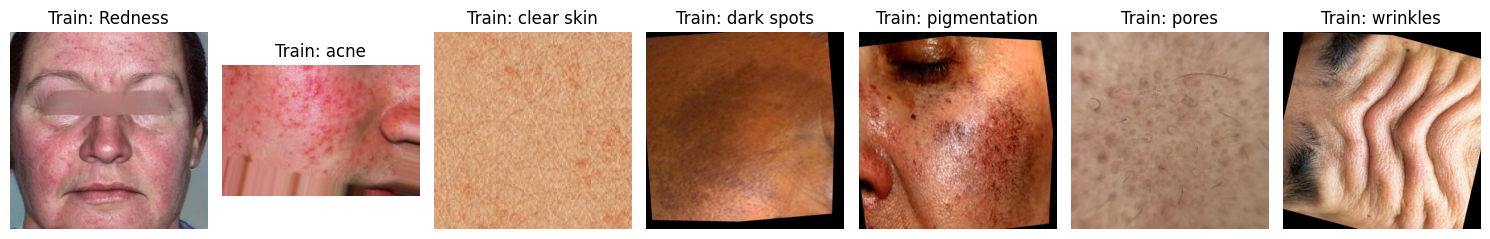


--- Samples from Validation Set ---


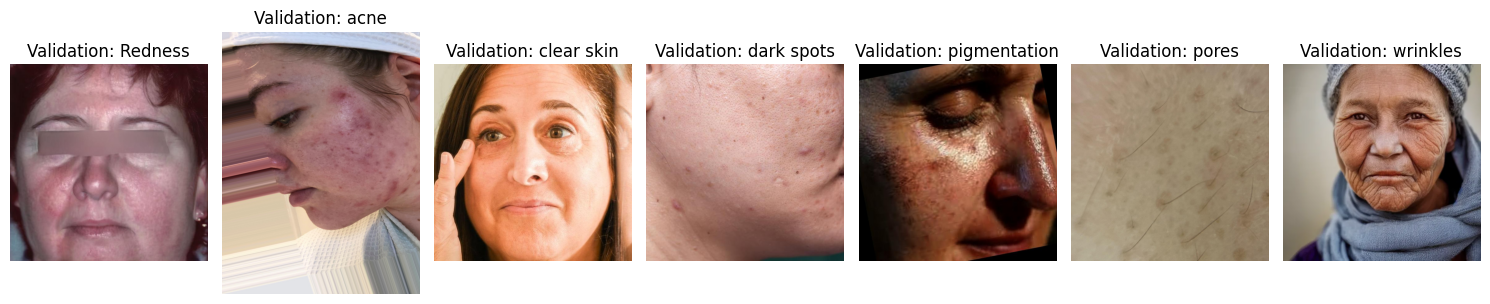


--- Samples from Test Set ---


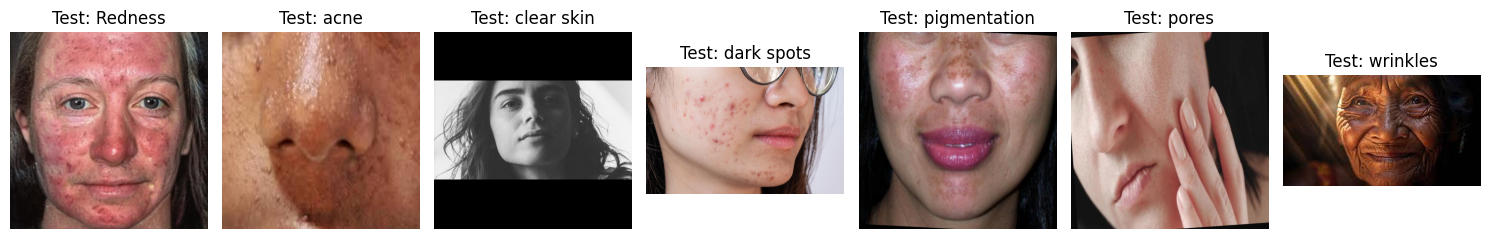

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import random
import os

def display_all_samples(base_path, task):
    task_path = os.path.join(base_path, task)
    splits = ['Train', 'Validation', 'Test']

    for split in splits:
        split_path = os.path.join(task_path, split)
        if not os.path.exists(split_path):
            print(f"Path not found: {split_path}")
            continue

        # Get directories (classes)
        classes = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))])

        if not classes:
            continue

        print(f"\n--- Samples from {split} Set ---")
        plt.figure(figsize=(15, 4))

        for i, cls in enumerate(classes):
            cls_path = os.path.join(split_path, cls)
            # Filter out hidden files like .DS_Store or ._ files common in Drive
            images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg')) and not f.startswith('.')]

            if images:
                # Try to find a valid image in the folder
                random.shuffle(images)
                img_loaded = False
                for img_name in images:
                    img_path = os.path.join(cls_path, img_name)
                    try:
                        img = Image.open(img_path)
                        plt.subplot(1, len(classes), i + 1)
                        plt.imshow(img)
                        plt.title(f"{split}: {cls}")
                        plt.axis('off')
                        img_loaded = True
                        break # Successfully loaded one image for this class
                    except Exception:
                        continue # Try the next image if one is corrupted

                if not img_loaded:
                     print(f"Could not load any valid images for class {cls} in {split} split.")
            else:
                print(f"No images found for class {cls} in {split} split.")

        plt.tight_layout()
        plt.show()

# Execute the function for 'Skin concerns'
display_all_samples(DATASET_BASE_PATH, 'Skin concerns')

Skin Concern Analyzer (ConvNeXt-Tiny)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import ConvNeXtTiny
import os
import json

# =====================================================================
# 1. EXPLICIT DIRECTORY SETUP (Targeting Skin Concerns)
# =====================================================================
SKIN_CONCERN_DIR = '/content/drive/MyDrive/Skin concerns'

def build_skin_concern_generators(target_dir):
    train_datagen = ImageDataGenerator(
        rotation_range=20, width_shift_range=0.2, height_shift_range=0.2,
        horizontal_flip=True, fill_mode='nearest'
    )
    test_datagen = ImageDataGenerator()

    train_gen = train_datagen.flow_from_directory(os.path.join(target_dir, 'Train'), target_size=(224, 224), batch_size=32, class_mode='categorical')
    val_gen = test_datagen.flow_from_directory(os.path.join(target_dir, 'Validation'), target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False)
    test_gen = test_datagen.flow_from_directory(os.path.join(target_dir, 'Test'), target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False)

    return train_gen, val_gen, test_gen

concern_train_gen, concern_val_gen, concern_test_gen = build_skin_concern_generators(SKIN_CONCERN_DIR)
num_concern_classes = len(concern_train_gen.class_indices)

with open('skin_concern_classes.json', 'w') as f:
    json.dump(concern_train_gen.class_indices, f)
print(f"✅ Isolated {num_concern_classes} Skin Concern Classes: {concern_train_gen.class_indices}")

# =====================================================================
# 2. CONVNEXT-TINY ARCHITECTURE
# =====================================================================
def build_concern_model(num_classes):
    base_model = ConvNeXtTiny(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model, base_model

skin_concern_model, concern_base_model = build_concern_model(num_concern_classes)

# =====================================================================
# 3. STAGE 1: WARMUP TRAINING
# =====================================================================
print("\n🚀 STAGE 1: Warmup Training (Frozen Backbone)...")
# Crucial: Added label_smoothing=0.1 for complex multi-feature image classes
skin_concern_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_concern_stage1 = skin_concern_model.fit(
    concern_train_gen,
    validation_data=concern_val_gen,
    epochs=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)

# =====================================================================
# 4. STAGE 2: DEEP FINE-TUNING
# =====================================================================
print("\n🔥 STAGE 2: Unfreezing Top Layers for Fine-Tuning...")
concern_base_model.trainable = True

# ConvNeXt layers are grouped differently; unfreezing the last 50 blocks/layers
for layer in concern_base_model.layers[:-50]:
    layer.trainable = False

skin_concern_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_concern_stage2 = skin_concern_model.fit(
    concern_train_gen,
    validation_data=concern_val_gen,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
    ]
)

# =====================================================================
# 5. FINAL EVALUATION & EXPORT
# =====================================================================
print("\n📊 Evaluating Model on Unseen Test Dataset...")
test_loss, test_acc = skin_concern_model.evaluate(concern_test_gen)
print(f"🏆 Final Test Accuracy: {test_acc * 100:.2f}%")

skin_concern_model.save('skin_concern_model.keras')
print("💾 Model successfully saved to 'skin_concern_model.keras'")

Found 5383 images belonging to 7 classes.
Found 468 images belonging to 7 classes.
Found 525 images belonging to 7 classes.
✅ Isolated 7 Skin Concern Classes: {'Redness': 0, 'acne': 1, 'clear skin': 2, 'dark spots': 3, 'pigmentation': 4, 'pores': 5, 'wrinkles': 6}
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

🚀 STAGE 1: Warmup Training (Frozen Backbone)...
Epoch 1/8
169/169 ━━━━━━━━━━━━━━━━━━━━ 1702s 10s/step - accuracy: 0.7485 - loss: 1.4669 - val_accuracy: 0.8291 - val_loss: 1.3603
Epoch 2/8
169/169 ━━━━━━━━━━━━━━━━━━━━ 122s 722ms/step - accuracy: 0.8456 - loss: 1.1947 - val_accuracy: 0.8632 - val_loss: 1.1243
Epoch 3/8
169/169 ━━━━━━━━━━━━━━━━━━━━ 119s 706ms/step - accuracy: 0.8661 - loss: 1.1094 - val_accuracy: 0.8483 - val_loss: 1.1240
Epoch 4/8
169/169 ━━━━━━━━━━━━━━━━━━━━ 118s 696ms/step - accuracy: 0.8798 - loss: 1.0431 - val_accuracy: 0.8632 - val_loss: 1.1156
Epoch 5/8
169/169 ━━━━━━━━━━━━━━━━━━━━ 115s 679ms/step - accuracy: 0.8980 - loss: 0.9828 - val_accuracy: 0.852

🏆 Final Test Accuracy: 90.48%


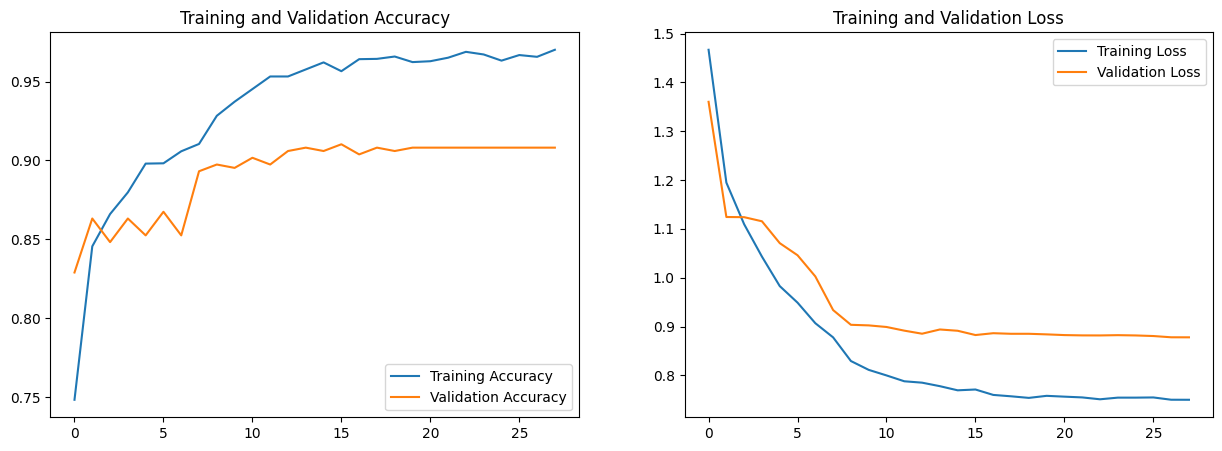


--- Generating Classification Metrics ---
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 739ms/step

Classification Report
              precision    recall  f1-score   support

     Redness       0.80      0.96      0.87        25
        acne       0.92      0.81      0.86       120
  clear skin       0.98      0.93      0.95       101
  dark spots       0.74      0.91      0.81       101
pigmentation       1.00      0.74      0.85        31
       pores       1.00      0.96      0.98        26
    wrinkles       0.99      0.99      0.99       121

    accuracy                           0.90       525
   macro avg       0.92      0.90      0.90       525
weighted avg       0.92      0.90      0.91       525



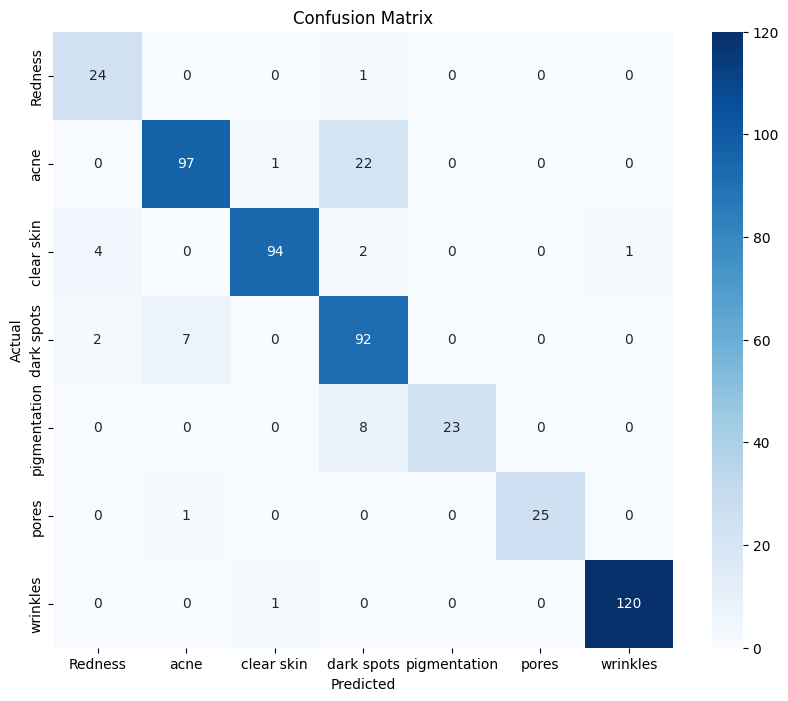

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Print Final Test Accuracy
print(f"🏆 Final Test Accuracy: {test_acc * 100:.2f}%")

# 2. Plot Training vs Validation Metrics (Combining Stage 1 and Stage 2)
acc = history_concern_stage1.history['accuracy'] + history_concern_stage2.history['accuracy']
val_acc = history_concern_stage1.history['val_accuracy'] + history_concern_stage2.history['val_accuracy']
loss = history_concern_stage1.history['loss'] + history_concern_stage2.history['loss']
val_loss = history_concern_stage1.history['val_loss'] + history_concern_stage2.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.show()

# 3. Confusion Matrix and Classification Report
print("\n--- Generating Classification Metrics ---")
Y_pred = skin_concern_model.predict(concern_test_gen)
y_pred = np.argmax(Y_pred, axis=1)

# Get class labels
target_names = list(concern_test_gen.class_indices.keys())

# Classification Report
print('\nClassification Report')
print(classification_report(concern_test_gen.classes, y_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(concern_test_gen.classes, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

it appears to be performing quite correctly. Here is why:

Accuracy Alignment: Your Training Accuracy 97% is close to your Validation Accuracy (~91%) and Test Accuracy (90.48%). A small gap (5-7%) is normal for deep learning; if it were overfitting, you would see ~99% training accuracy with a much lower validation accuracy (e.g., 60-70%).
Loss Convergence: The training and validation loss curves both trend downward together. The validation loss does not start increasing sharply while training loss decreases, which is the classic sign of overfitting.
Balanced Performance: The Confusion Matrix and Classification Report show high F1-scores across most classes (especially 'wrinkles' at 0.99 and 'pores' at 0.98). The model struggled slightly more with 'dark spots', but overall the performance is robust.
Conclusion
The model is well-trained. The use of Dropout and label_smoothing helped generalize the model effectively to unseen data.

In [ ]:
from google.colab import files

# Trigger the download of the model file
files.download('skin_concern_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Testing and comaparing before after image

📸 STEP 1: Upload the BASELINE (Before) Image


Saving before 2.jpg to before 2 (1).jpg

📸 STEP 2: Upload the FOLLOW-UP (After) Image


Saving Gemini_Generated_Image_utxxs4utxxs4utxx.png to Gemini_Generated_Image_utxxs4utxxs4utxx (1).png

⏳ Analyzing images using the trained model... Please wait.



🔬 AI SKIN CONCERN PROGRESS & COMPARISON REPORT
📌 BASELINE PRIMARY CONCERN: DARK SPOTS (29.06%)
📌 FOLLOW-UP PRIMARY CONCERN: CLEAR SKIN (62.88%)


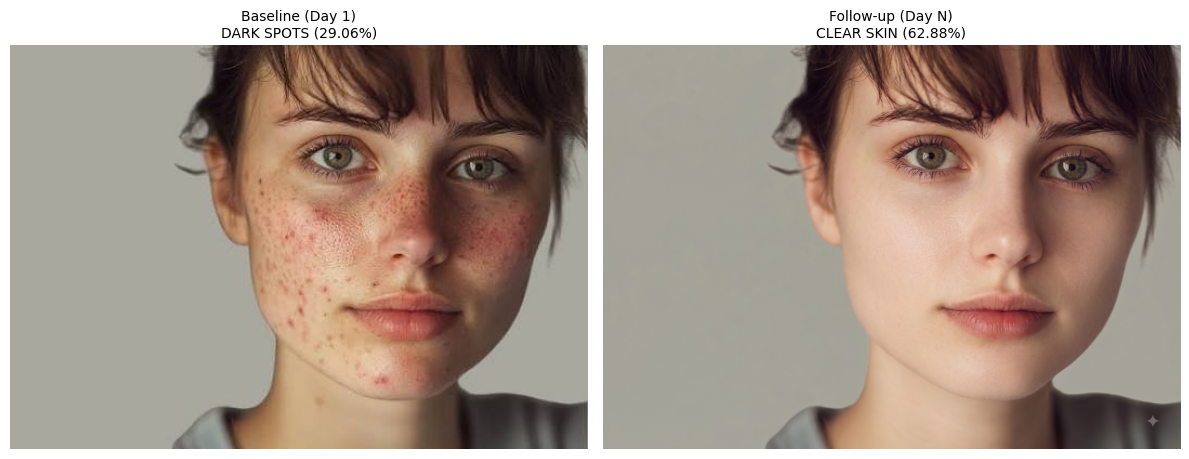


📊 DETAILED CONCERN BREAKDOWN & DELTA (Δ):
Skin Concern       | Baseline %   | Follow-up %  | Change (Δ)     
----------------------------------------------------------------------
Dark Spots         |     29.06%   |     12.54%   |   -16.52% (📉 Improved)
Clear Skin         |     21.32%   |     62.88%   |   +41.56% (📈 Improved)
Redness            |     20.02%   |     11.43%   |    -8.59% (📉 Improved)
Acne               |     12.68%   |      7.75%   |    -4.93% (📉 Improved)
Wrinkles           |     10.73%   |      4.83%   |    -5.90% (📉 Improved)
Pigmentation       |      4.63%   |      0.33%   |    -4.30% (📉 Improved)
Pores              |      1.57%   |      0.24%   |    -1.33% (📉 Improved)
----------------------------------------------------------------------

⚠️ OUTCOME: Active primary concern remains: 'Clear Skin'.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import json
import matplotlib.pyplot as plt
from google.colab import files
import os

# =====================================================================
# 1. LOAD MODEL & CLASS MAPPINGS
# =====================================================================
model_path = 'skin_concern_model.keras'
if not os.path.exists(model_path):
    print(f"❌ Error: {model_path} not found. Make sure you ran the training cell first.")
else:
    # Loading the model you just trained
    skin_concern_model = tf.keras.models.load_model(model_path)

    with open('skin_concern_classes.json', 'r') as f:
        class_indices = json.load(f)

    # Invert dictionary to map index -> class name
    index_to_class = {v: k for k, v in class_indices.items()}

# =====================================================================
# 2. SINGLE IMAGE INFERENCE FUNCTION
# =====================================================================
def analyze_skin_concern(img_path):
    # Preprocessing: target_size must match the (224, 224) used in training
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # The model was trained with ConvNeXt which handles scaling internally.
    # We pass raw pixel values [0-255] as done in the build_generators function.
    predictions = skin_concern_model.predict(img_array, verbose=0)[0]

    concern_scores = {}
    for idx, prob in enumerate(predictions):
        concern_scores[index_to_class[idx]] = round(float(prob) * 100, 2)

    # Sorting to find the top prediction
    sorted_concerns = dict(sorted(concern_scores.items(), key=lambda item: item[1], reverse=True))
    primary_concern = list(sorted_concerns.keys())[0]
    primary_confidence = sorted_concerns[primary_concern]

    return {
        "primary_concern": primary_concern,
        "primary_confidence": primary_confidence,
        "all_concerns_percent": sorted_concerns
    }

# =====================================================================
# 3. DUAL-IMAGE COMPARISON ENGINE
# =====================================================================
def compare_skin_progress(img_baseline_path, img_followup_path):
    print("\n⏳ Analyzing images using the trained model... Please wait.")
    baseline_res = analyze_skin_concern(img_baseline_path)
    followup_res = analyze_skin_concern(img_followup_path)

    print("\n" + "=" * 80)
    print("🔬 AI SKIN CONCERN PROGRESS & COMPARISON REPORT")
    print("=" * 80)

    # Explicitly show primary concerns for both images
    print(f"📌 BASELINE PRIMARY CONCERN: {baseline_res['primary_concern'].upper()} ({baseline_res['primary_confidence']}%)")
    print(f"📌 FOLLOW-UP PRIMARY CONCERN: {followup_res['primary_concern'].upper()} ({followup_res['primary_confidence']}%)")

    # Visual display
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    img1 = image.load_img(img_baseline_path)
    axes[0].imshow(img1)
    axes[0].set_title(f"Baseline (Day 1)\n{baseline_res['primary_concern'].upper()} ({baseline_res['primary_confidence']}%)", fontsize=10)
    axes[0].axis('off')

    img2 = image.load_img(img_followup_path)
    axes[1].imshow(img2)
    axes[1].set_title(f"Follow-up (Day N)\n{followup_res['primary_concern'].upper()} ({followup_res['primary_confidence']}%)", fontsize=10)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # Detailed Delta Table
    print("\n📊 DETAILED CONCERN BREAKDOWN & DELTA (Δ):")
    print(f"{'Skin Concern':<18} | {'Baseline %':<12} | {'Follow-up %':<12} | {'Change (Δ)':<15}")
    print("-" * 70)

    for concern in baseline_res['all_concerns_percent']:
        b_score = baseline_res['all_concerns_percent'][concern]
        f_score = followup_res['all_concerns_percent'][concern]
        delta = round(f_score - b_score, 2)

        if concern == 'clear skin':
            indicator = "📈 Improved" if delta > 0 else "📉 Reduced"
        else:
            indicator = "📉 Improved" if delta < 0 else "📈 Increased"

        print(f"{concern.title():<18} | {b_score:>9.2f}%   | {f_score:>9.2f}%   | {delta:>+8.2f}% ({indicator})")

    print("-" * 70)

    # Decision logic
    clear_skin_pct = followup_res['all_concerns_percent'].get('clear skin', 0)
    if clear_skin_pct >= 90.0:
        print(f"\n🎉 OUTCOME: Skin condition is largely cleared ({clear_skin_pct}%).")
    else:
        print(f"\n⚠️ OUTCOME: Active primary concern remains: '{followup_res['primary_concern'].title()}'.")

# =====================================================================
# 4. INTERACTIVE UPLOAD BLOCKS
# =====================================================================
print("📸 STEP 1: Upload the BASELINE (Before) Image")
baseline_upload = files.upload()
if len(baseline_upload) > 0:
    baseline_filename = list(baseline_upload.keys())[0]

    print("\n📸 STEP 2: Upload the FOLLOW-UP (After) Image")
    followup_upload = files.upload()

    if len(followup_upload) > 0:
        followup_filename = list(followup_upload.keys())[0]
        compare_skin_progress(baseline_filename, followup_filename)
    else:
        print("❌ No Follow-up image uploaded.")
else:
    print("❌ No Baseline image uploaded.")